# Library Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import plot_model
from keras.losses import categorical_crossentropy
from keras.layers import Dense, Embedding, Flatten
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# Drive Permision

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Import

In [3]:
df = pd.read_csv("/content/humor_dataset.csv")

In [4]:
df.head()

,id,text,target
0,1,TENNESSEE: We're the best state. Nobody even c...,1
1,2,A man inserted an advertisement in the classif...,1
2,3,How many men does it take to open a can of bee...,1
3,4,Told my mom I hit 1200 Twitter followers. She ...,1
4,5,Roses are dead. Love is fake. Weddings are bas...,1


In [5]:
df.shape

(8000, 3)

# Preprocessing - Data Cleaning

In [6]:
df = df[['text','target']]

In [7]:
df.dtypes

,0
text,object
target,int64


In [8]:
max_sentence_length = df['text'].fillna('').apply(lambda x: len(x.split())).max()

print("Maximum Sentence Length:", max_sentence_length)

Maximum Sentence Length: 63


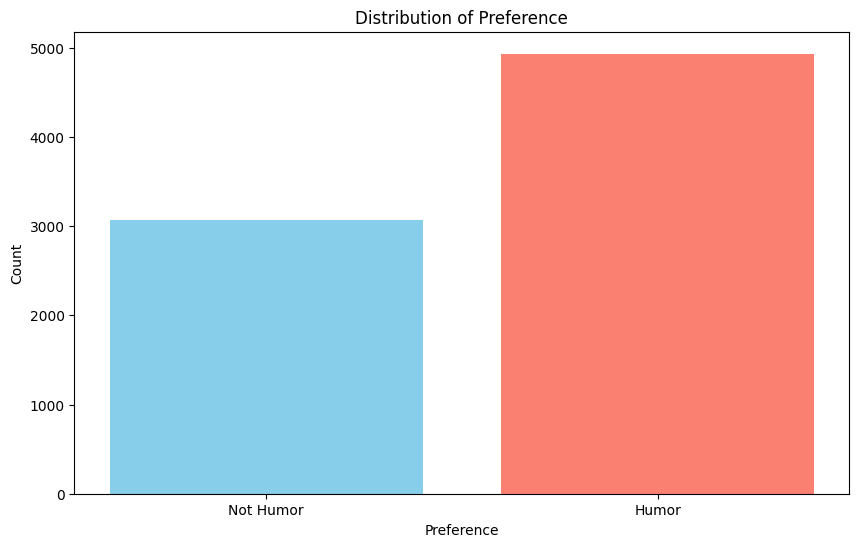

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

counts = df['target'].value_counts().sort_index()
labels = ['Not Humor', 'Humor']  # 0 = Not Humor, 1 = Humor

plt.bar(labels, counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Preference')
plt.xlabel('Preference')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [10]:
df.isnull().sum()

,0
text,0
target,0


In [11]:
df.duplicated(subset=['text']).sum()

np.int64(0)

In [12]:
import re
import unicodedata
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalize
    text = unicodedata.normalize("NFKC", text)

    # Remove zero-width characters
    text = re.sub(r'[\u200B-\u200D\uFEFF]', '', text)

    # Replace fancy quotes with normal
    text = text.replace("\u2018", "'").replace("\u2019", "'")
    text = text.replace("\u201C", '"').replace("\u201D", '"')

    # Remove dashes (– —) but keep hyphen in words
    text = re.sub(r'[–—]', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove HTML tags/entities
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'&amp;', '&', text)

    # Remove noisy punctuation (keep ! ? . , ' ")
    text = re.sub(r'[`#*^()°~×|;@$><+=_\\]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Lowercase
    text = text.lower()

    return text

# Apply to dataset
df = pd.read_csv('humor_dataset.csv')
df['clean_text'] = df['text'].apply(clean_text)

# Preview
print(df[['text', 'clean_text']].head())

                                                text  \
0  TENNESSEE: We're the best state. Nobody even c...   
1  A man inserted an advertisement in the classif...   
2  How many men does it take to open a can of bee...   
3  Told my mom I hit 1200 Twitter followers. She ...   
4  Roses are dead. Love is fake. Weddings are bas...   

                                          clean_text  
0  tennessee: we're the best state. nobody even c...  
1  a man inserted an advertisement in the classif...  
2  how many men does it take to open a can of bee...  
3  told my mom i hit 1200 twitter followers. she ...  
4  roses are dead. love is fake. weddings are bas...  


In [13]:
df.head(10)

,id,text,target,clean_text
0,1,TENNESSEE: We're the best state. Nobody even c...,1,tennessee: we're the best state. nobody even c...
1,2,A man inserted an advertisement in the classif...,1,a man inserted an advertisement in the classif...
2,3,How many men does it take to open a can of bee...,1,how many men does it take to open a can of bee...
3,4,Told my mom I hit 1200 Twitter followers. She ...,1,told my mom i hit 1200 twitter followers. she ...
4,5,Roses are dead. Love is fake. Weddings are bas...,1,roses are dead. love is fake. weddings are bas...
5,6,"'Trabajo,' the Spanish word for work, comes fr...",0,"'trabajo,' the spanish word for work, comes fr..."
6,7,I enrolled on some skill training and extra cu...,0,i enrolled on some skill training and extra cu...
7,8,ME: I'm such an original. Truly one of a kind....,1,me: i'm such an original. truly one of a kind....
8,9,Men who ejaculated 21 times or more a month ha...,0,men who ejaculated 21 times or more a month ha...
9,10,I got REALLY angry today and it wasn't about n...,0,i got really angry today and it wasn't about n...


In [14]:
def tokenized_data(text):
    tokenized_text = text.split()
    return tokenized_text

In [15]:
seq_length = 300

In [16]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stop_words(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['clean_text'].apply(remove_stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
df['c_text'] = df['text'].apply(clean_text)
df['c_text'] = df['c_text'].apply(remove_stop_words)

In [18]:
df.head(10)

,id,text,target,clean_text,c_text
0,1,TENNESSEE: We're the best state. Nobody even c...,1,tennessee: best state. nobody even comes close...,tennessee: best state. nobody even comes close...
1,2,A man inserted an advertisement in the classif...,1,"man inserted advertisement classifieds ""wife w...","man inserted advertisement classifieds ""wife w..."
2,3,How many men does it take to open a can of bee...,1,many men take open beer? none. open time bring...,many men take open beer? none. open time bring...
3,4,Told my mom I hit 1200 Twitter followers. She ...,1,told mom hit 1200 twitter followers. pointed b...,told mom hit 1200 twitter followers. pointed b...
4,5,Roses are dead. Love is fake. Weddings are bas...,1,roses dead. love fake. weddings basically fune...,roses dead. love fake. weddings basically fune...
5,6,"'Trabajo,' the Spanish word for work, comes fr...",0,"'trabajo,' spanish word work, comes latin term...","'trabajo,' spanish word work, comes latin term..."
6,7,I enrolled on some skill training and extra cu...,0,enrolled skill training extra curricula activi...,enrolled skill training extra curricula activi...
7,8,ME: I'm such an original. Truly one of a kind....,1,me: original. truly one kind. also me: [holdin...,me: original. truly one kind. also me: [holdin...
8,9,Men who ejaculated 21 times or more a month ha...,0,men ejaculated 21 times month lower risk prost...,men ejaculated 21 times month lower risk prost...
9,10,I got REALLY angry today and it wasn't about n...,0,"got really angry today nothing, going take wor...","got really angry today nothing, going take wor..."


In [19]:
df['c_text'].head(30)

,c_text
0,tennessee: best state. nobody even comes close...
1,"man inserted advertisement classifieds ""wife w..."
2,many men take open beer? none. open time bring...
3,told mom hit 1200 twitter followers. pointed b...
4,roses dead. love fake. weddings basically fune...
5,"'trabajo,' spanish word work, comes latin term..."
6,enrolled skill training extra curricula activi...
7,me: original. truly one kind. also me: [holdin...
8,men ejaculated 21 times month lower risk prost...
9,"got really angry today nothing, going take wor..."


In [20]:
label_encoder = LabelEncoder()
df['target_encoded'] = label_encoder.fit_transform(df['target'])

print("Original Target Labels:", label_encoder.classes_)
print("Encoded Target Samples:")
display(df[['target', 'target_encoded']].head(100))

Original Target Labels: [0 1]
Encoded Target Samples:


,target,target_encoded
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
95,1,1
96,1,1
97,1,1
98,1,1


In [21]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.9 MB/s eta 0:00:00


In [22]:
import gensim.downloader as api

print("Loading pretrained Word2Vec model...")
w2v_model = api.load("word2vec-google-news-300")  # 300-dim pretrained vectors
print("Word2Vec model loaded.")

Loading pretrained Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model loaded.


In [23]:
def document_vector(word2vec_model, document):
    words = [word for word in document.split() if word in word2vec_model]
    if not words:
        return np.zeros(300)  # changed from 100 to 300
    return np.mean([word2vec_model[word] for word in words], axis=0)


print("Creating document vectors...")
X_w2v = np.array([document_vector(w2v_model, text) for text in df['c_text']])
y_w2v = df['target_encoded']
print("Document vectors created. Shape:", X_w2v.shape)

Creating document vectors...
Document vectors created. Shape: (8000, 300)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_w2v, y_w2v, test_size=0.3, random_state=42, stratify=y_w2v)

print("Shape of X_train_w2v:", X_train.shape)
print("Shape of X_test_w2v:", X_test.shape)
print("Shape of y_train_w2v:", y_train.shape)
print("Shape of y_test_w2v:", y_test.shape)


print("\nSentiment distribution in y_train (counts):\n", pd.Series(y_train).value_counts())
print("\nSentiment distribution in y_test (counts):\n", pd.Series(y_test).value_counts())

Shape of X_train_w2v: (5600, 300)
Shape of X_test_w2v: (2400, 300)
Shape of y_train_w2v: (5600,)
Shape of y_test_w2v: (2400,)

Sentiment distribution in y_train (counts):
 target_encoded
1    3452
0    2148
Name: count, dtype: int64

Sentiment distribution in y_test (counts):
 target_encoded
1    1480
0     920
Name: count, dtype: int64


# RF

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Training Random Forest Classifier")
rf_model.fit(X_train, y_train)
print("Training complete.")

Training Random Forest Classifier
Training complete.


In [26]:
y_pred = rf_model.predict(X_test)


print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred, target_names=['Not Humor', 'Humor']))


Classification Report for Random Forest:
              precision    recall  f1-score   support

   Not Humor       0.79      0.61      0.69       920
       Humor       0.79      0.90      0.84      1480

    accuracy                           0.79      2400
   macro avg       0.79      0.76      0.76      2400
weighted avg       0.79      0.79      0.78      2400




Confusion Matrix for Random Forest


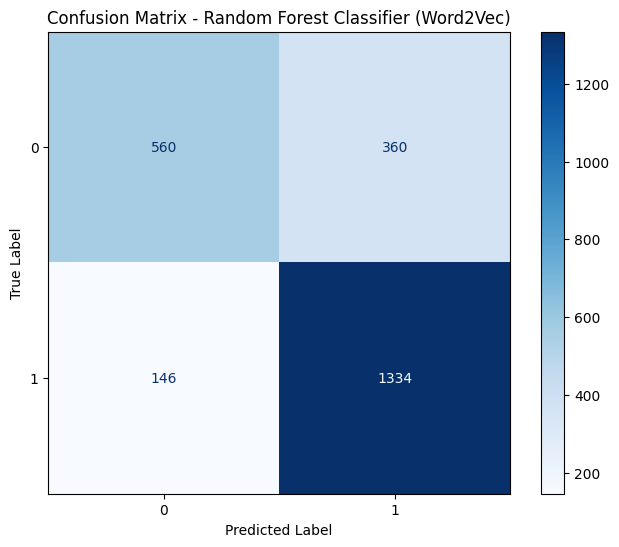

In [27]:
print("\nConfusion Matrix for Random Forest")
fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=label_encoder.classes_)
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Random Forest Classifier (Word2Vec)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

# KNN

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_model = KNeighborsClassifier(
    n_neighbors=1,
    metric='minkowski',
    weights='distance'
)

print("Training KNN Classifier")
knn_model.fit(X_train_scaled, y_train)
print("Training complete.")

Training KNN Classifier
Training complete.


In [29]:
y_pred = knn_model.predict(X_test_scaled)


print("\nClassification Report for KNN:")
print(classification_report(y_test, y_pred, target_names=['Not Humor', 'Humor']))


Classification Report for KNN:
              precision    recall  f1-score   support

   Not Humor       0.61      0.73      0.67       920
       Humor       0.81      0.71      0.76      1480

    accuracy                           0.72      2400
   macro avg       0.71      0.72      0.71      2400
weighted avg       0.73      0.72      0.72      2400




Confusion Matrix for KNN


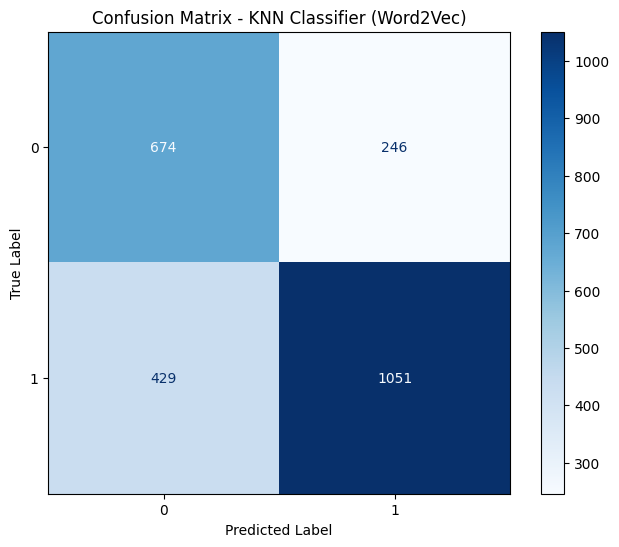

In [30]:
print("\nConfusion Matrix for KNN")
fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - KNN Classifier (Word2Vec)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

# XGB

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost Classifier")
xgb_model.fit(X_train, y_train)
print("Training complete.")

Training XGBoost Classifier
Training complete.


In [32]:
y_pred = xgb_model.predict(X_test)


print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred, target_names=['Not Humor', 'Humor']))


Classification Report for XGBoost:
              precision    recall  f1-score   support

   Not Humor       0.80      0.71      0.75       920
       Humor       0.83      0.89      0.86      1480

    accuracy                           0.82      2400
   macro avg       0.81      0.80      0.81      2400
weighted avg       0.82      0.82      0.82      2400




Confusion Matrix for XGBoost


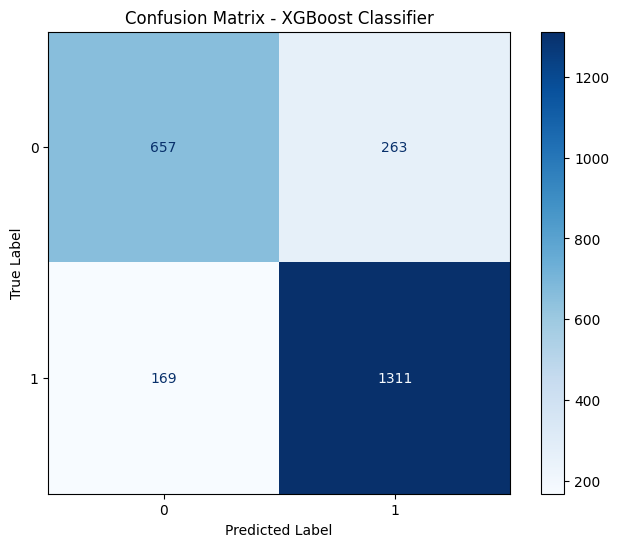

In [33]:
print("\nConfusion Matrix for XGBoost")
fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

# DT

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42
)

print("Training Decision Tree Classifier")
dt_model.fit(X_train, y_train)
print("Training complete.")


y_pred = dt_model.predict(X_test)

Training Decision Tree Classifier
Training complete.


In [35]:
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred, target_names=['Not Humor', 'Humor']))


Classification Report for Decision Tree:
              precision    recall  f1-score   support

   Not Humor       0.55      0.57      0.56       920
       Humor       0.72      0.71      0.72      1480

    accuracy                           0.65      2400
   macro avg       0.63      0.64      0.64      2400
weighted avg       0.66      0.65      0.65      2400




Confusion Matrix for Decision Tree


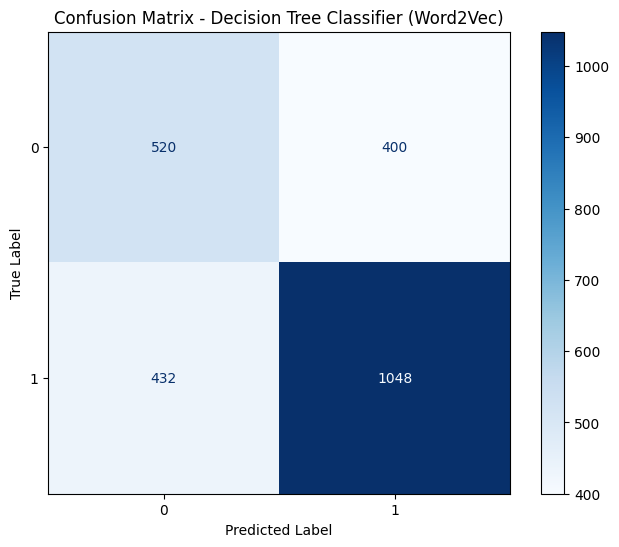

In [36]:
print("\nConfusion Matrix for Decision Tree")
fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Decision Tree Classifier (Word2Vec)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

# SVM

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=False,
    random_state=42
)

print("Training SVM Classifier")
svm_model.fit(X_train_scaled, y_train)
print("Training complete.")

Training SVM Classifier
Training complete.


In [38]:

y_pred = svm_model.predict(X_test_scaled)


print("\nClassification Report for SVM:")
print(classification_report(y_test, y_pred, target_names=['Not Humor', 'Humor']))


Classification Report for SVM:
              precision    recall  f1-score   support

   Not Humor       0.80      0.74      0.77       920
       Humor       0.85      0.89      0.87      1480

    accuracy                           0.83      2400
   macro avg       0.83      0.81      0.82      2400
weighted avg       0.83      0.83      0.83      2400




Confusion Matrix for SVM


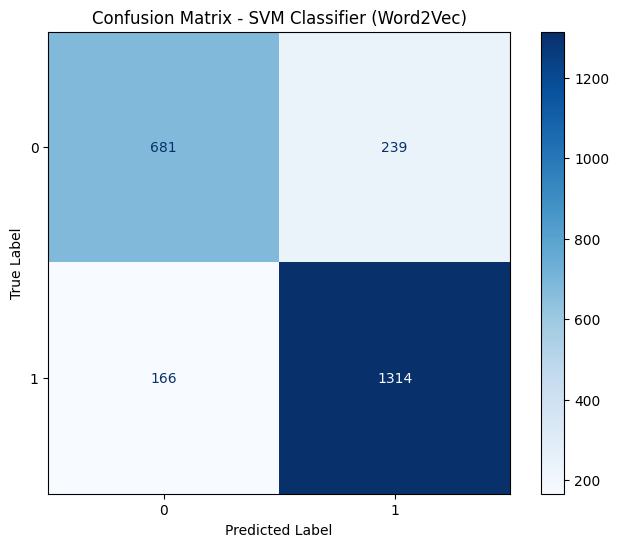

In [39]:
print("\nConfusion Matrix for SVM")
fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - SVM Classifier (Word2Vec)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Conv1D, MaxPooling1D,
                                      Dense, Dropout, Flatten, Bidirectional, Input, concatenate)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tokenization
MAX_VOCAB  = 20000
MAX_LEN    = 100
EMBED_DIM  = 300

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['c_text'])

X_seq = tokenizer.texts_to_sequences(df['c_text'])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')
y_arr = df['target'].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_pad, y_arr, test_size=0.3, random_state=42, stratify=y_arr)

print("Train shape:", X_train_seq.shape)
print("Test shape :", X_test_seq.shape)

Train shape: (5600, 100)
Test shape : (2400, 100)


In [41]:
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_VOCAB, EMBED_DIM))
for word, idx in word_index.items():
    if idx < MAX_VOCAB and word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (20000, 300)


In [42]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],    label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_dl_model(name, model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    print(f"\n{'='*50}")
    print(f"Classification Report — {name}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Not Humor', 'Humor']))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Not Humor', 'Humor']
    ).plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix — {name}')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - accuracy: 0.6143 - loss: 0.6713 - val_accuracy: 0.6080 - val_loss: 0.6699
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 52s 743ms/step - accuracy: 0.6185 - loss: 0.6684 - val_accuracy: 0.6080 - val_loss: 0.6696
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 29s 415ms/step - accuracy: 0.6185 - loss: 0.6666 - val_accuracy: 0.6080 - val_loss: 0.6696
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 30s 429ms/step - accuracy: 0.6185 - loss: 0.6669 - val_accuracy: 0.6080 - val_loss: 0.6698
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 422ms/step - accuracy: 0.6185 - loss: 0.6676 - val_accuracy: 0.6080 - val_loss: 0.6697


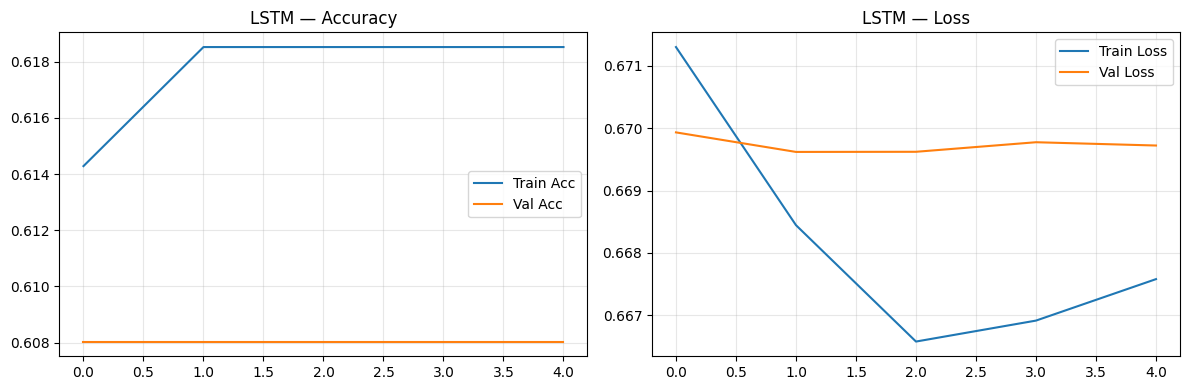

75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step

Classification Report — LSTM
              precision    recall  f1-score   support

   Not Humor       0.00      0.00      0.00       920
       Humor       0.62      1.00      0.76      1480

    accuracy                           0.62      2400
   macro avg       0.31      0.50      0.38      2400
weighted avg       0.38      0.62      0.47      2400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


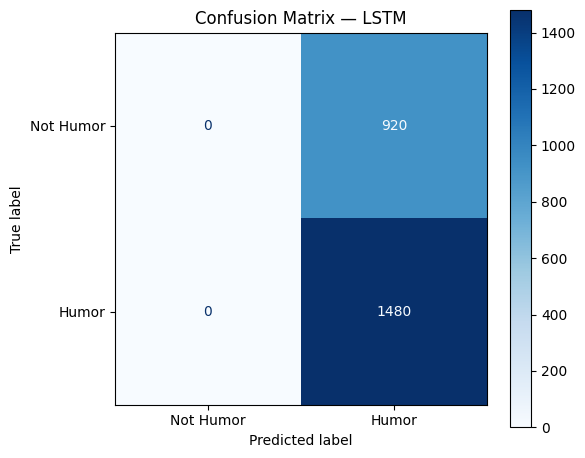

In [43]:
lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, weights=[embedding_matrix],
              input_length=MAX_LEN, trainable=False),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),
    LSTM(64,  dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_lstm, "LSTM")
evaluate_dl_model("LSTM", lstm_model, X_test_seq, y_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 413ms/step - accuracy: 0.6123 - loss: 0.6713 - val_accuracy: 0.6080 - val_loss: 0.6711
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 425ms/step - accuracy: 0.6185 - loss: 0.6663 - val_accuracy: 0.6080 - val_loss: 0.6697
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 28s 399ms/step - accuracy: 0.6185 - loss: 0.6673 - val_accuracy: 0.6080 - val_loss: 0.6706


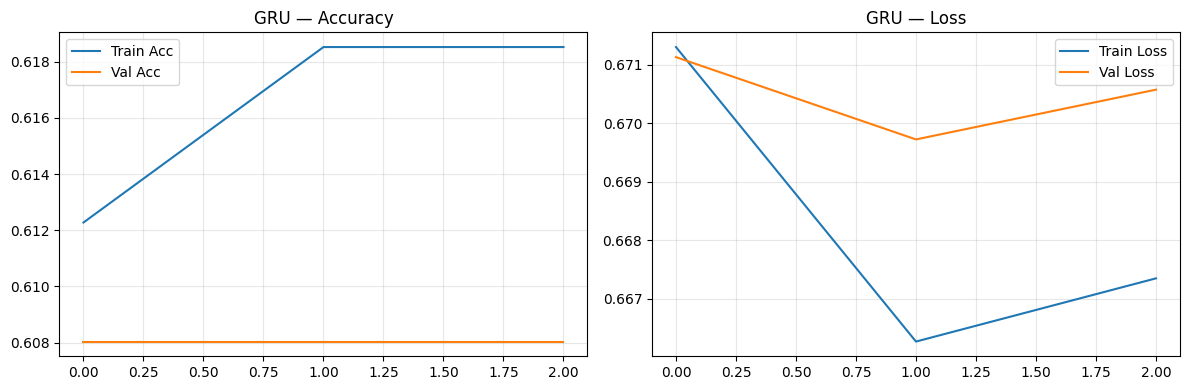

75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step

Classification Report — GRU
              precision    recall  f1-score   support

   Not Humor       0.00      0.00      0.00       920
       Humor       0.62      1.00      0.76      1480

    accuracy                           0.62      2400
   macro avg       0.31      0.50      0.38      2400
weighted avg       0.38      0.62      0.47      2400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


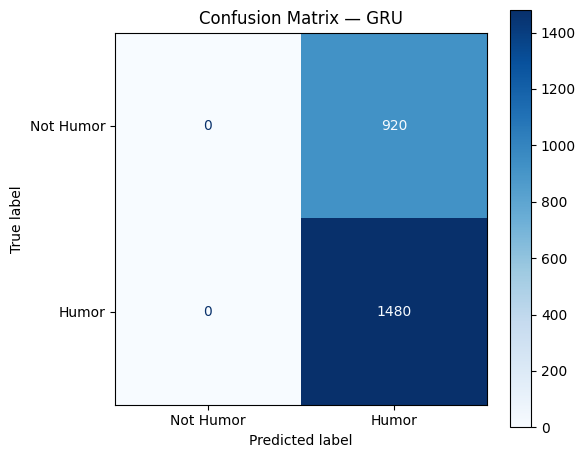

In [44]:
gru_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, weights=[embedding_matrix],
              input_length=MAX_LEN, trainable=False),
    GRU(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),
    GRU(64,  dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.summary()

history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_gru, "GRU")
evaluate_dl_model("GRU", gru_model, X_test_seq, y_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.7511 - loss: 0.5022 - val_accuracy: 0.8313 - val_loss: 0.4150
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8746 - loss: 0.3072 - val_accuracy: 0.8464 - val_loss: 0.3776
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9384 - loss: 0.1656 - val_accuracy: 0.8402 - val_loss: 0.4260
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9835 - loss: 0.0602 - val_accuracy: 0.8268 - val_loss: 0.5897
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9960 - loss: 0.0214 - val_accuracy: 0.8313 - val_loss: 0.6635


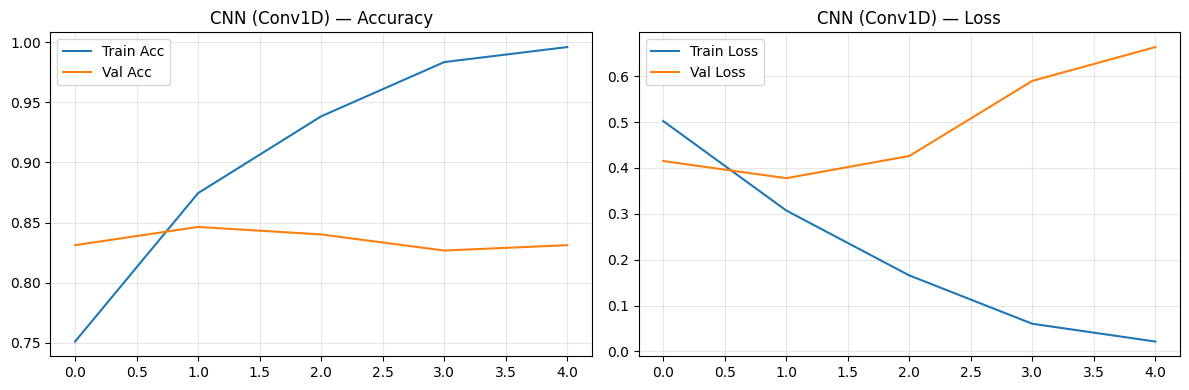

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report — CNN (Conv1D)
              precision    recall  f1-score   support

   Not Humor       0.81      0.79      0.80       920
       Humor       0.87      0.88      0.88      1480

    accuracy                           0.85      2400
   macro avg       0.84      0.84      0.84      2400
weighted avg       0.85      0.85      0.85      2400



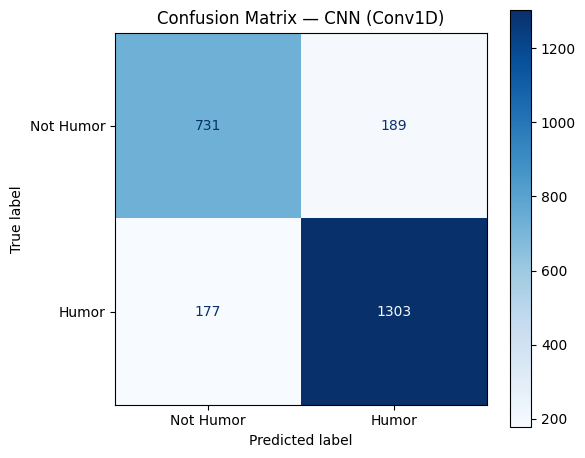

In [45]:
cnn_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, weights=[embedding_matrix],
              input_length=MAX_LEN, trainable=False),
    Conv1D(128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

history_cnn = cnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_cnn, "CNN (Conv1D)")
evaluate_dl_model("CNN (Conv1D)", cnn_model, X_test_seq, y_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.6123 - loss: 0.6593 - val_accuracy: 0.6080 - val_loss: 0.6741
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.6192 - loss: 0.6686 - val_accuracy: 0.6080 - val_loss: 0.6698
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.6185 - loss: 0.6682 - val_accuracy: 0.6080 - val_loss: 0.6700


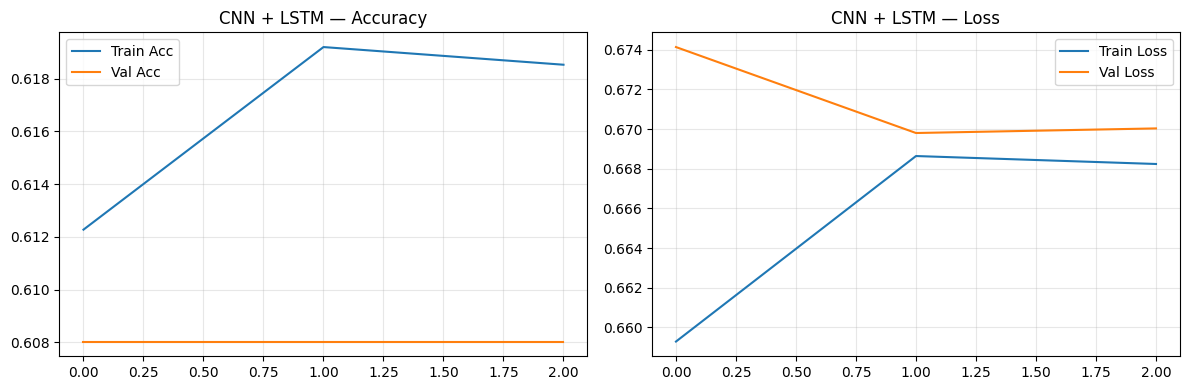

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step

Classification Report — CNN + LSTM
              precision    recall  f1-score   support

   Not Humor       0.00      0.00      0.00       920
       Humor       0.62      1.00      0.76      1480

    accuracy                           0.62      2400
   macro avg       0.31      0.50      0.38      2400
weighted avg       0.38      0.62      0.47      2400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


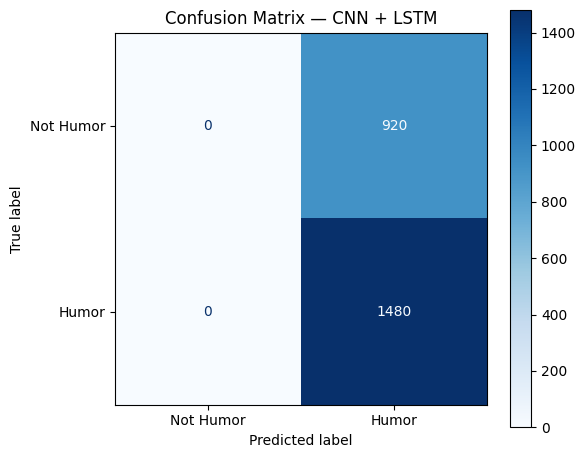

In [46]:
cnn_lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, weights=[embedding_matrix],
              input_length=MAX_LEN, trainable=False),
    Conv1D(128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),
    LSTM(64,  dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

cnn_lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_lstm_model.summary()

history_cnn_lstm = cnn_lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plot_history(history_cnn_lstm, "CNN + LSTM")
evaluate_dl_model("CNN + LSTM", cnn_lstm_model, X_test_seq, y_test_seq)

In [47]:
!pip uninstall transformers -y

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0


In [48]:
!pip install transformers==4.40.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [49]:
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import tensorflow as tf

# ── 1. Load tokenizer ────────────────────────────────────────────────
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# ── 2. Encode function ───────────────────────────────────────────────
def bert_encode(texts, max_len=128):
    input_ids, attention_masks = [], []
    for text in texts:
        encoded = bert_tokenizer(
            text,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])
    return np.array(input_ids), np.array(attention_masks)

# ── 3. Encode texts ──────────────────────────────────────────────────
print("Encoding texts for BERT (this takes a few minutes)...")
X_input_ids, X_attention_masks = bert_encode(df['c_text'].tolist(), max_len=128)
y_arr = df['target'].to_numpy()   # ✅ Fixed: 'label' → 'target'
print("Encoding complete.")

# ── 4. Single clean train/test split ────────────────────────────────
(X_ids_train,  X_ids_test,
 X_mask_train, X_mask_test,
 y_bert_train, y_bert_test) = train_test_split(
    X_input_ids,
    X_attention_masks,
    y_arr,
    test_size=0.2,
    random_state=42,
    stratify=y_arr
)

print(f"Train size: {len(X_ids_train)}, Test size: {len(X_ids_test)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Encoding texts for BERT (this takes a few minutes)...
Encoding complete.
Train size: 6400, Test size: 1600


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  Train Loss: 0.3129 | Train Acc: 0.8645
  Val   Loss: 0.2141   | Val   Acc: 0.9181

Epoch 2/3


Evaluating: 100%|██████████| 100/100 [00:13<00:00,  7.36it/s]


  Train Loss: 0.1129 | Train Acc: 0.9611
  Val   Loss: 0.2166   | Val   Acc: 0.9206

Epoch 3/3


Evaluating: 100%|██████████| 100/100 [00:13<00:00,  7.45it/s]


  Train Loss: 0.0518 | Train Acc: 0.9817
  Val   Loss: 0.2408   | Val   Acc: 0.9256


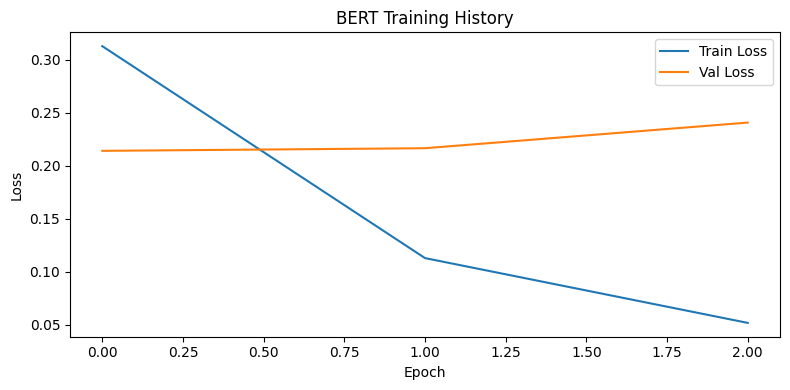

In [50]:
# ── Install required packages ─────────────────────────────────────────
!pip install transformers torch scikit-learn -q

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── 1. Dataset class ──────────────────────────────────────────────────
class HumorDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts, max_length=max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

# ── 2. Tokenizer & splits ─────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

texts  = df['c_text'].tolist()
labels = df['target'].tolist()

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = HumorDataset(X_train_txt, y_train, tokenizer)
test_dataset  = HumorDataset(X_test_txt,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# ── 3. Model setup ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
).to(device)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# ── 4. Training loop ──────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for batch in tqdm(loader, desc="Training"):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
        loss    = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.logits.argmax(dim=1) == labels_batch).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# ── 5. Evaluation loop ────────────────────────────────────────────────
def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['labels'].to(device)

            outputs     = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
            total_loss += outputs.loss.item()
            correct    += (outputs.logits.argmax(dim=1) == labels_batch).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# ── 6. Run training ───────────────────────────────────────────────────
EPOCHS = 3
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(bert_model, train_loader, optimizer, device)
    val_loss,   val_acc   = eval_epoch(bert_model,  test_loader,  device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.4f}")

# ── 7. Plot loss ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.title('BERT Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


Classification Report — BERT
              precision    recall  f1-score   support

   Not Humor       0.90      0.91      0.90       614
       Humor       0.94      0.94      0.94       986

    accuracy                           0.93      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.93      0.93      0.93      1600



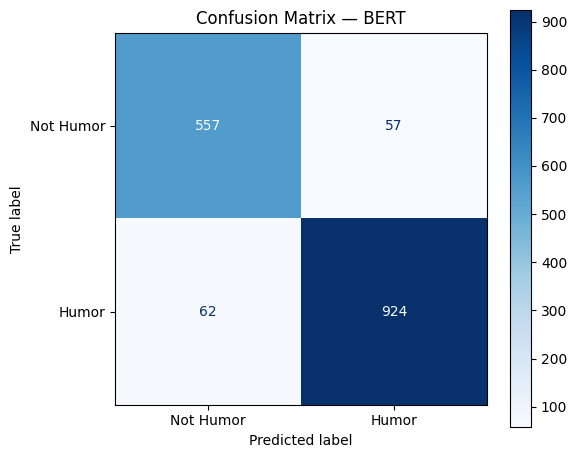

In [52]:
# ── 8. Final classification report ───────────────────────────────────
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1).cpu().tolist()  # ✅ tolist() instead of numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].tolist())                   # ✅ tolist() instead of numpy()

print("\n" + "="*50)
print("Classification Report — BERT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Not Humor', 'Humor']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(all_labels, all_preds),
    display_labels=['Not Humor', 'Humor']
).plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix — BERT')
plt.grid(False)
plt.tight_layout()
plt.show()